In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style(style='dark')
from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score

In [2]:
data=pd.read_csv('data.csv')

In [3]:
data

,x0,x1,y
0,3.269556,2.170835,0.0
1,2.499932,3.662437,0.0
2,3.473768,1.834280,0.0
3,0.673961,0.051743,0.0
4,3.788682,2.736997,0.0
...,...,...,...
195,4.769000,4.335009,1.0
196,3.067705,3.685545,1.0
197,4.702616,3.446341,1.0
198,2.364729,2.770822,1.0


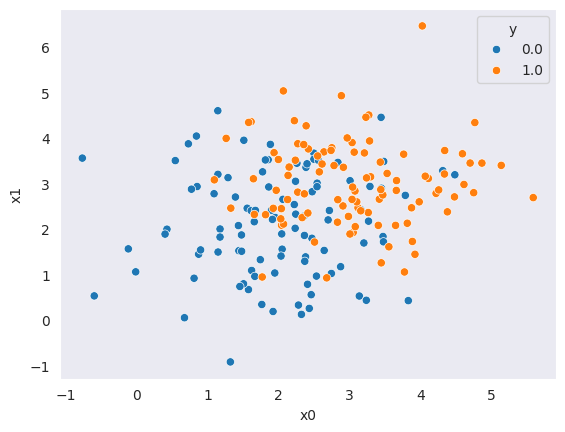

In [7]:
sns.scatterplot(x=data['x0'], y=data['x1'], hue=data['y'])
plt.show()

In [8]:
X=data.drop(columns='y')
y=data.y

In [12]:
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=42, random_state=42)

In [22]:
per=Perceptron(penalty='l1', n_jobs=-1)

In [23]:
per.fit(X_train, y_train)

Perceptron(n_jobs=-1, penalty='l1')

In [30]:
y_pred_train=per.predict(X_train)
print('-'*15, "Training Results", '-'*15)
print("Accuracy Score: ",accuracy_score(y_train, y_pred_train))
print("Precision Score: ",precision_score(y_train, y_pred_train))
print("Recall Score: ",recall_score(y_train, y_pred_train))

--------------- Training Results ---------------
Accuracy Score:  0.7025316455696202
Precision Score:  0.632
Recall Score:  0.9875


In [31]:
y_pred=per.predict(X_test)
print('-'*15, "Test Results", '-'*15)
print("Accuracy Score: ",accuracy_score(y_test, y_pred))
print("Precision Score: ",precision_score(y_test, y_pred))
print("Recall Score: ",recall_score(y_test, y_pred))

--------------- Test Results ---------------
Accuracy Score:  0.6428571428571429
Precision Score:  0.5757575757575758
Recall Score:  0.95


In [33]:
per.coef_

array([[9.59450797, 7.29733731]])

In [34]:
per.intercept_

array([-32.])

In [38]:
from mlxtend.plotting import plot_decision_regions

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Perceptron was fitted with feature names
  warnings.warn(


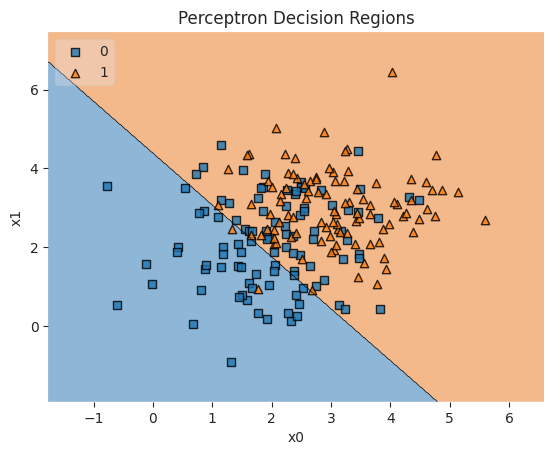

In [42]:
import numpy as np
plot_decision_regions(X.values, y.values.astype(np.int_), clf=per, legend=2)
plt.xlabel('x0')
plt.ylabel('x1')
plt.title('Perceptron Decision Regions')
plt.show()